In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

In [2]:
df = pd.read_csv('updated_data.csv')

In [3]:
df.describe()

,row_id,postal_code,sales,quantity,discount,profit,price
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,60.919569
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,142.927440
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.336000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,5.470000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,16.270000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,63.940000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,3773.080000


In [4]:
df.isnull().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
day_name         0
price            0
dtype: int64

In [5]:
print(df['category'].value_counts())
print(df['sub-category'].value_counts())

category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64
sub-category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


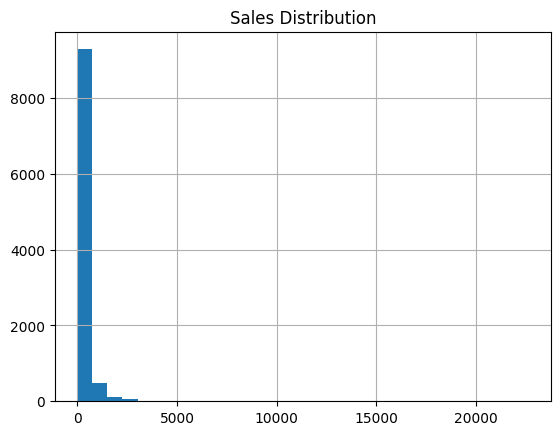

In [6]:
df['sales'].hist(bins=30)
plt.title('Sales Distribution')
plt.show()

In [7]:
corr = df[['sales', 'profit', 'discount', 'quantity']].corr()


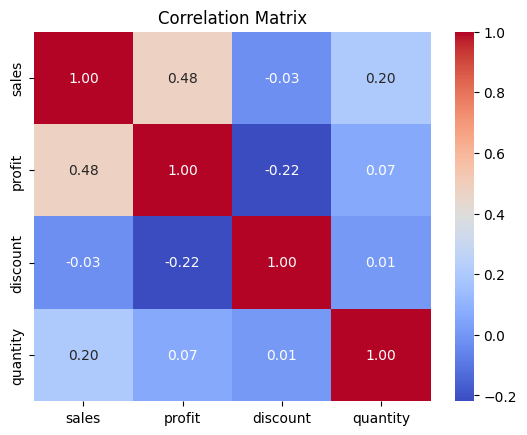

In [8]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [9]:
# Q: Is profit significantly different across regions?
east  = df[df['region']=='East']['profit']
west  = df[df['region']=='West']['profit']

t_stat, p_value = stats.ttest_ind(east, west)
print(f"p-value: {p_value:.4f}")
# If p < 0.05 → significant difference exists

# ANOVA across all 4 regions
groups = [df[df['region']==r]['profit'] for r in df['region'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA p-value: {p_val:.4f}")

p-value: 0.7561
ANOVA p-value: 0.0489


In [10]:
df['region'].value_counts()

region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [11]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit', 'day_name',
       'price'],
      dtype='object')

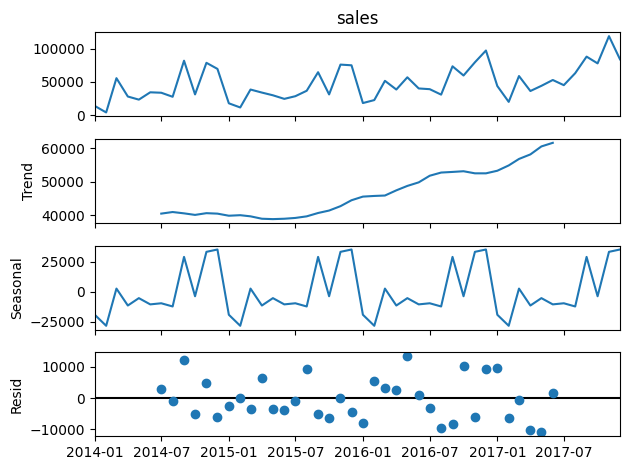

In [12]:
monthly = df.groupby(pd.to_datetime(df['order_date']).dt.to_period('M'))['sales'].sum()
monthly.index = monthly.index.to_timestamp()

result = seasonal_decompose(monthly, model='additive', period=12)
result.plot()
plt.show()


In [13]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,day_name,price
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Weekday,130.9800
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,Weekday,243.9800
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Weekend,7.3100
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,Weekend,191.5155
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Weekend,11.1840


supervised machine learning problem



In [14]:
!pip install xgboost

In [15]:

import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score)

In [16]:
y = df['profit']
 
x = df[['sales', 'quantity', 'discount', 'price',
         'category', 'sub-category', 'region',
         'segment', 'ship_mode']]

In [17]:
x.head()

,sales,quantity,discount,price,category,sub-category,region,segment,ship_mode
0,261.9600,2,0.00,130.9800,Furniture,Bookcases,South,Consumer,Second Class
1,731.9400,3,0.00,243.9800,Furniture,Chairs,South,Consumer,Second Class
2,14.6200,2,0.00,7.3100,Office Supplies,Labels,West,Corporate,Second Class
3,957.5775,5,0.45,191.5155,Furniture,Tables,South,Consumer,Standard Class
4,22.3680,2,0.20,11.1840,Office Supplies,Storage,South,Consumer,Standard Class


In [18]:
categorical_cols = ['category', 'sub-category', 'region', 'segment', 'ship_mode']
numerical_cols   = ['sales', 'quantity', 'discount', 'price']

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'   # numerical cols pass through unchanged
)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape[0]} rows")
print(f"Test  size: {X_test.shape[0]} rows\n")
 

Train size: 7995 rows
Test  size: 1999 rows



In [21]:
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [22]:
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,    # number of trees
        max_depth=10,        # max depth per tree (prevents overfitting)
        min_samples_split=5, # min samples to split a node
        random_state=42,
        n_jobs=-1            # use all CPU cores
    ))
])

In [23]:
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,    # number of boosting rounds
        learning_rate=0.05,  # step size (lower = more careful)
        max_depth=6,         # tree depth
        subsample=0.8,       # use 80% of rows per tree
        colsample_bytree=0.8,# use 80% of features per tree
        random_state=42,
        verbosity=0
    ))
])

In [24]:
models = {
    'Linear Regression': pipe_lr,
    'Random Forest'    : pipe_rf,
    'XGBoost'          : pipe_xgb,
}

In [25]:
# STEP 5 — Train, predict, evaluate all 3 models

results = {}
predictions = {}
 
print("=" * 55)
print(f"{'Model':<22} {'R²':>7} {'RMSE':>9} {'MAE':>9}")
print("=" * 55)

for name, pipe in models.items():
    # Train
    pipe.fit(X_train, y_train)
 
    # Predict on test set
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred
 
    # Metrics
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
 
    # Cross-validation R² (5-fold) — more reliable than single split
    cv_scores = cross_val_score(pipe, x, y, cv=5, scoring='r2')
 
    results[name] = {
        'r2'      : r2,
        'rmse'    : rmse,
        'mae'     : mae,
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
        'pipeline': pipe,
        'y_pred'  : y_pred,
    }
 
    print(f"{name:<22} {r2:>7.4f} {rmse:>9.2f} {mae:>9.2f}")
 
print("=" * 55)

Model                       R²      RMSE       MAE
Linear Regression      -0.6113    279.51     67.06
Random Forest           0.0134    218.71     28.93
XGBoost                 0.7071    119.17     21.35


In [26]:
best_name = max(results, key=lambda m: results[m]['cv_mean'])
best      = results[best_name]
 
print(f"\n BEST MODEL: {best_name}")
print(f"   Test R²        : {best['r2']:.4f}  → model explains {best['r2']*100:.1f}% of profit variance")
print(f"   RMSE           : {best['rmse']:.2f}  → avg prediction error ±{best['rmse']:.0f} profit units")
print(f"   MAE            : {best['mae']:.2f}  → median error ±{best['mae']:.0f}")
print(f"   CV R² (5-fold) : {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")
 
# R² interpretation
r2 = best['r2']
if r2 >= 0.85:
    verdict = "Excellent "
elif r2 >= 0.70:
    verdict = "Good "
elif r2 >= 0.50:
    verdict = "Moderate "
else:
    verdict = "Weak fit "
print(f"   Verdict        : {verdict}")


✓ BEST MODEL: XGBoost
   Test R²        : 0.7071  → model explains 70.7% of profit variance
   RMSE           : 119.17  → avg prediction error ±119 profit units
   MAE            : 21.35  → median error ±21
   CV R² (5-fold) : 0.8285 ± 0.0822
   Verdict        : Good 


In [27]:
if best_name in ['Random Forest', 'XGBoost']:
    ohe_cols = (best['pipeline']
                .named_steps['preprocessor']
                .named_transformers_['cat']
                .get_feature_names_out(categorical_cols))
    feature_names = list(ohe_cols) + numerical_cols
 
    importances = (best['pipeline']
                   .named_steps['model']
                   .feature_importances_)
 
    fi_df = (pd.DataFrame({'feature': feature_names,
                            'importance': importances})
             .sort_values('importance', ascending=False)
             .head(12))
else:
    fi_df = None

In [49]:
comparison_df = pd.DataFrame({
    'Actual Profit': y_test.values,
    'Predicted Profit': y_pred_best
})

comparison_df.sample(5)

,Actual Profit,Predicted Profit
795,76.2525,53.015221
514,-55.2560,-40.675926
365,40.4160,32.718723
427,10.0878,9.879391
1831,22.9920,24.940187


Figure(1600x1200)
Axes count: 4


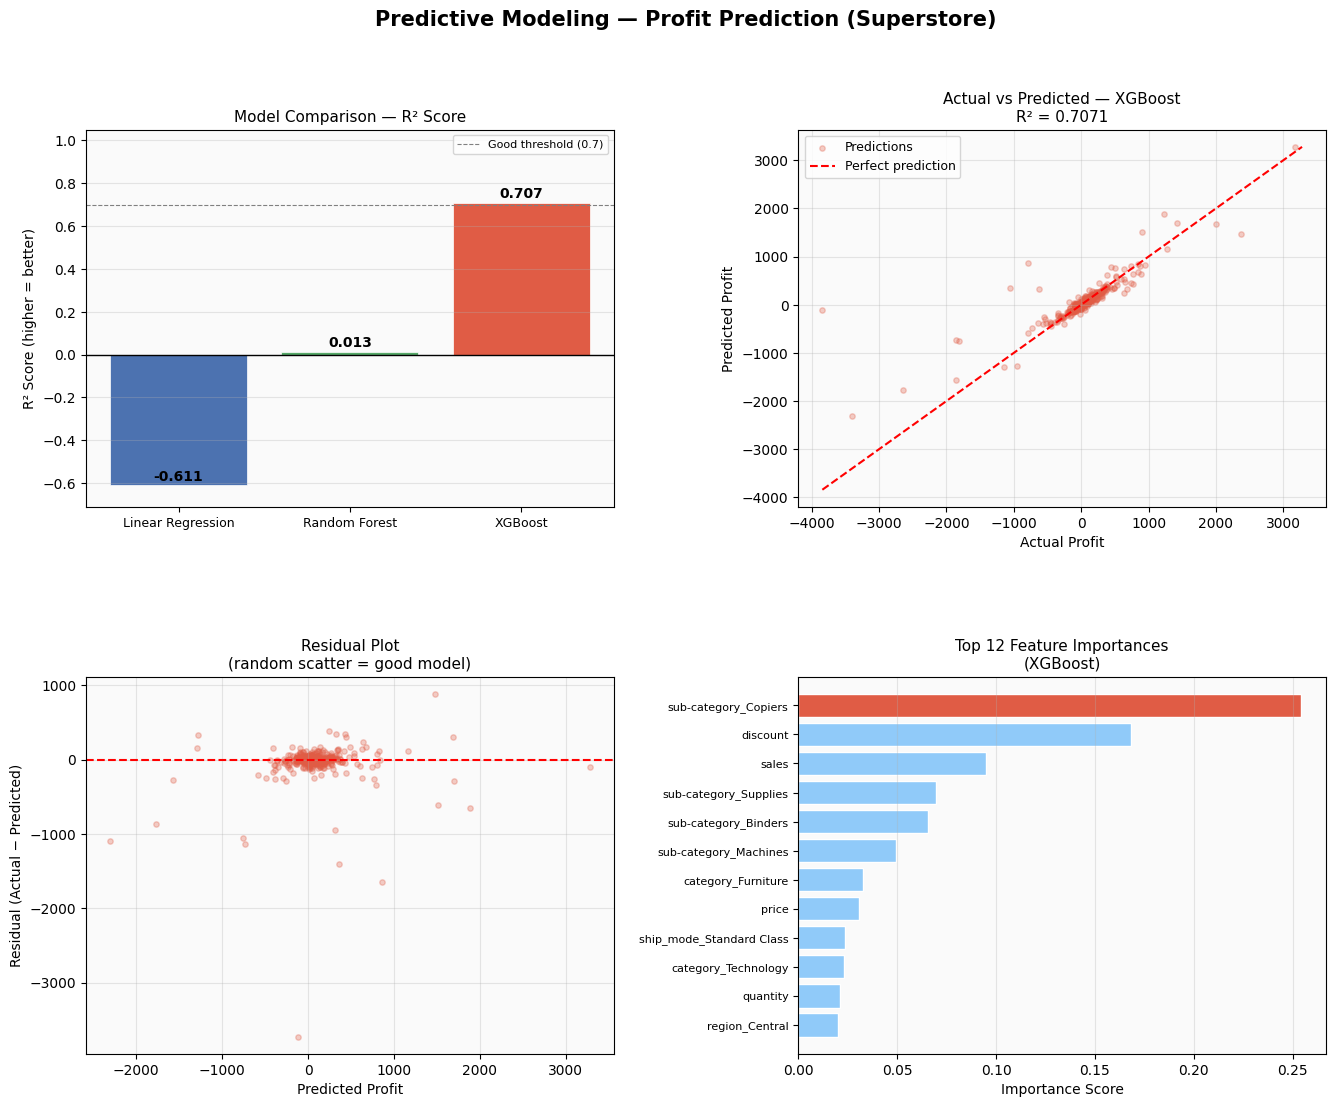


✓ Chart saved → predictive_modeling.png


In [48]:
# STEP 8 — Visualization (4 subplots)
# ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
plt.clf()
fig.suptitle('Predictive Modeling — Profit Prediction (Superstore)',
             fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)
 
COLORS = {'Linear Regression': '#4C72B0',
          'Random Forest'    : '#55A868',
          'XGBoost'          : '#E05C45'}
 
# ── Plot 1: Model comparison bar chart ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
names = list(results.keys())
r2s   = [results[m]['r2']   for m in names]
rmses = [results[m]['rmse'] for m in names]
bars  = ax1.bar(names, r2s,
                color=[COLORS[m] for m in names],
                edgecolor='white', linewidth=0.5)
ax1.set_ylim(min(r2s)-0.1, 1.05)
ax1.axhline(
    y=0,
    color='black',
    linewidth=1
)
ax1.set_ylabel('R² Score (higher = better)', fontsize=10)
ax1.set_title('Model Comparison — R² Score', fontsize=11)
ax1.axhline(0.7, color='gray', linestyle='--', linewidth=0.8,
            label='Good threshold (0.7)')
ax1.legend(fontsize=8)
for bar, val in zip(bars, r2s):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xticklabels(names, fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.set_facecolor('#FAFAFA')
 

#2
ax2 = fig.add_subplot(gs[0, 1])
y_pred_best = best['y_pred']
ax2.scatter(y_test, y_pred_best, alpha=0.3, s=15,
            color=COLORS[best_name], label='Predictions')
lims = [min(y_test.min(), y_pred_best.min()),
        max(y_test.max(), y_pred_best.max())]
ax2.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax2.set_xlabel('Actual Profit', fontsize=10)
ax2.set_ylabel('Predicted Profit', fontsize=10)
ax2.set_title(f'Actual vs Predicted — {best_name}\nR² = {best["r2"]:.4f}', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_facecolor('#FAFAFA')

#3
# ── Plot 3: Residual plot ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
residuals = y_test.values - y_pred_best
ax3.scatter(y_pred_best, residuals, alpha=0.3, s=15,
            color=COLORS[best_name])
ax3.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Predicted Profit', fontsize=10)
ax3.set_ylabel('Residual (Actual − Predicted)', fontsize=10)
ax3.set_title('Residual Plot\n(random scatter = good model)', fontsize=11)
ax3.grid(alpha=0.3)
ax3.set_facecolor('#FAFAFA')

#4
# ── Plot 4: Feature Importance OR RMSE comparison ───────────
ax4 = fig.add_subplot(gs[1, 1])
if fi_df is not None:
    colors_fi = ['#E05C45' if i == 0 else '#90CAF9'
                 for i in range(len(fi_df))]
    ax4.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
             color=colors_fi[::-1], edgecolor='white')
    ax4.set_xlabel('Importance Score', fontsize=10)
    ax4.set_title(f'Top 12 Feature Importances\n({best_name})', fontsize=11)
    ax4.tick_params(axis='y', labelsize=8)
    ax4.grid(axis='x', alpha=0.3)
else:
    # For Linear Regression: show all 3 RMSE bars
    rmse_vals = [results[m]['rmse'] for m in names]
    bars2 = ax4.bar(names, rmse_vals,
                    color=[COLORS[m] for m in names],
                    edgecolor='white')
    ax4.set_ylabel('RMSE (lower = better)', fontsize=10)
    ax4.set_title('Model Comparison — RMSE', fontsize=11)
    for bar, val in zip(bars2, rmse_vals):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)
    ax4.grid(axis='y', alpha=0.3)
ax4.set_facecolor('#FAFAFA')
print(fig)
print("Axes count:", len(fig.axes))
plt.tight_layout()
plt.show()
 
plt.savefig('predictive_modeling.png', dpi=150, bbox_inches='tight', facecolor='white')
print("\n✓ Chart saved → predictive_modeling.png")
plt.close()